# Import Modules and Functions

In [1]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
### Read in data that has been flagged for good indices

lc_df1i = readin_LCdf('LC_tables/modified_data/LCtable1_i.csv')
lc_df1g = readin_LCdf('LC_tables/modified_data/LCtable1_g.csv')
lc_df1r = readin_LCdf('LC_tables/modified_data/LCtable1_r.csv')
lc_df1z = readin_LCdf('LC_tables/modified_data/LCtable1_z.csv')

lc_df2i = readin_LCdf('LC_tables/modified_data/LCtable2_i.csv')
lc_df2g = readin_LCdf('LC_tables/modified_data/LCtable2_g.csv')
lc_df2r = readin_LCdf('LC_tables/modified_data/LCtable2_r.csv')
lc_df2z = readin_LCdf('LC_tables/modified_data/LCtable2_z.csv')

lc_df3i = readin_LCdf('LC_tables/modified_data/LCtable3_i.csv')
lc_df3g = readin_LCdf('LC_tables/modified_data/LCtable3_g.csv')
lc_df3r = readin_LCdf('LC_tables/modified_data/LCtable3_r.csv')
lc_df3z = readin_LCdf('LC_tables/modified_data/LCtable3_z.csv')

lc_df4i = readin_LCdf('LC_tables/modified_data/LCtable4_i.csv')
lc_df4g = readin_LCdf('LC_tables/modified_data/LCtable4_g.csv')
lc_df4r = readin_LCdf('LC_tables/modified_data/LCtable4_r.csv')
lc_df4z = readin_LCdf('LC_tables/modified_data/LCtable4_z.csv')


lc_dfs1 = [lc_df1g, lc_df1r, lc_df1i, lc_df1z]
lc_dfs2 = [lc_df2g, lc_df2r, lc_df2i, lc_df2z]
lc_dfs3 = [lc_df3g, lc_df3r, lc_df3i, lc_df3z]
lc_dfs4 = [lc_df4g, lc_df4r, lc_df4i, lc_df4z]

# Fitting Process

In [4]:
### Fit light curves to one position (one light curve) per segment per filter simultaneously

temp_ID1 = 7
mcres_1 = loop_allemcee(lc_dfs1, temp_ID=temp_ID1, peak_l='main')

temp_ID2 = 55
mcres_2 = loop_allemcee(lc_dfs2, temp_ID=temp_ID2, peak_l='main')

temp_ID3 = 93
mcres_3 = loop_allemcee(lc_dfs3, temp_ID=temp_ID3, peak_l='plat')

temp_ID4 = 23
mcres_4 = loop_allemcee(lc_dfs4, temp_ID=temp_ID4, peak_l=None)

In [5]:
### Combine aligned light curves into one data frame per segment per filter

comb1 = get_allcombLCs(lc_dfs1, mcres_1)
comb2 = get_allcombLCs(lc_dfs2, mcres_2)
comb3 = get_allcombLCs(lc_dfs3, mcres_3)
comb4 = get_allcombLCs(lc_dfs4, mcres_4)

In [6]:
### Fit segments together per filter simultaneously

mpeak1i = comb1[2].t['mjd'].values[np.argmax(comb1[2].t['muJyas2'].values)]
mpeak2i = comb2[2].t['mjd'].values[np.argmax(comb2[2].t['muJyas2'].values)]
mcres_21 = fit_allsegdata(comb2, comb1, tshift_i=mpeak1i-mpeak2i, shift_tol=180.0)

pinds2i = comb2[2].ix_inrange('mjd', lowlim=59100, uplim=59500)
pinds3i = comb3[2].ix_inrange('mjd', lowlim=57500, uplim=58000)
mpeak2i = comb2[2].t.loc[pinds2i,'mjd'].values[np.argmax(comb2[2].t.loc[pinds2i,'muJyas2'].values)]
mpeak3i = comb3[2].t.loc[pinds3i,'mjd'].values[np.argmax(comb3[2].t.loc[pinds3i,'muJyas2'].values)]
mcres_23 = fit_allsegdata(comb2, comb3, tshift_i=mpeak3i-mpeak2i, shift_tol=180.0)

new_comb3 = update_allcomb(comb3, mcres_23)
mcres_34 = fit_allsegdata(new_comb3, comb4, tshift_i=-4450, shift_tol=180.0)

In [7]:
### Fit for baseline per filter -- tail end goes to zero

offsets = fit_alltail(comb4, mcres_34, plot=False)

In [8]:
### Combine aligned data of the four segments per filter

fin_combs = comb_allcomb([comb1, comb2, comb3, comb4], [mcres_21, None, mcres_23, mcres_34], offsets)

In [9]:
### Create model

fmods = [optimizeGP_celer(fcb, lc_ID=None) for fcb in fin_combs]

In [10]:
### Sigma cut using model
fin_inds = [sigmacut_df(fin_combs[i], fmods[i], sigma=3.0) for i in range(len(fin_combs))]

In [11]:
### Create final model
fin_mods = [optimizeGP_celer(fin_combs[i], lc_ID=None, indices=fin_inds[i]) for i in range(len(fin_combs))]

In [12]:
### Save tables

fin_combs[0].t.to_csv('LC_tables/models/gLC_data1.csv', index=False)
fin_combs[1].t.to_csv('LC_tables/models/rLC_data1.csv', index=False)
fin_combs[2].t.to_csv('LC_tables/models/iLC_data1.csv', index=False)
fin_combs[3].t.to_csv('LC_tables/models/zLC_data1.csv', index=False)

fin_mods[0].t.to_csv('LC_tables/models/gLC_mod1.csv', index=False)
fin_mods[1].t.to_csv('LC_tables/models/rLC_mod1.csv', index=False)
fin_mods[2].t.to_csv('LC_tables/models/iLC_mod1.csv', index=False)
fin_mods[3].t.to_csv('LC_tables/models/zLC_mod1.csv', index=False)

# Plot

In [13]:
### See fits

# plot_allLCfits(lc_dfs4, mcres_4, templ_ID=temp_ID4)

In [14]:
### Plot segments

# sflt = 2
# see_combs = [comb1[sflt], comb2[sflt], comb3[sflt], comb4[sflt]]

# plt.errorbar(see_combs[0].t['mjd'], see_combs[0].t['muJyas2'], yerr=see_combs[0].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb1i, mu_comb1i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[1].t['mjd'], see_combs[1].t['muJyas2'], yerr=see_combs[1].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb2i, mu_comb2i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[2].t['mjd'], see_combs[2].t['muJyas2'], yerr=see_combs[2].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb3i, mu_comb3i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[3].t['mjd'], see_combs[3].t['muJyas2'], yerr=see_combs[3].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb4i, mu_comb4i, color='k', zorder=5)
# plt.show()

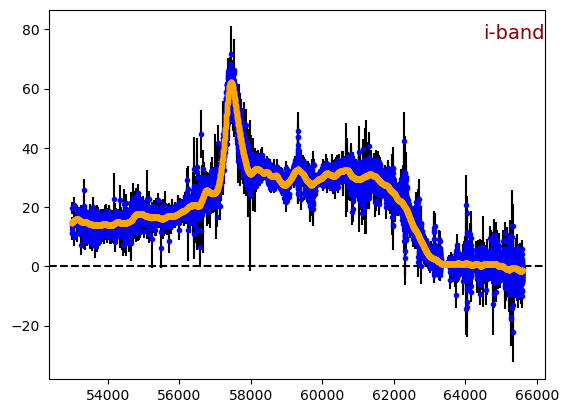

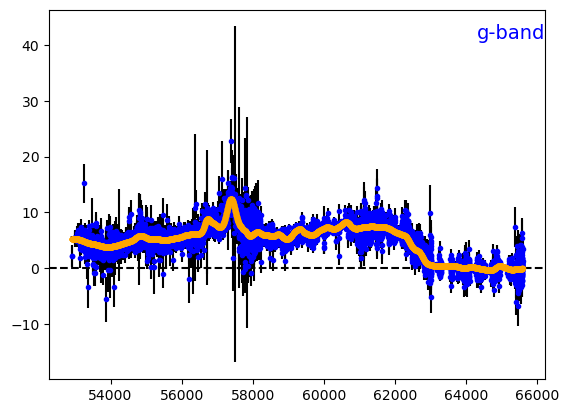

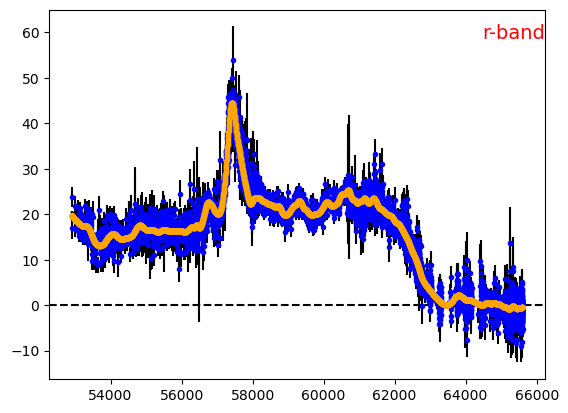

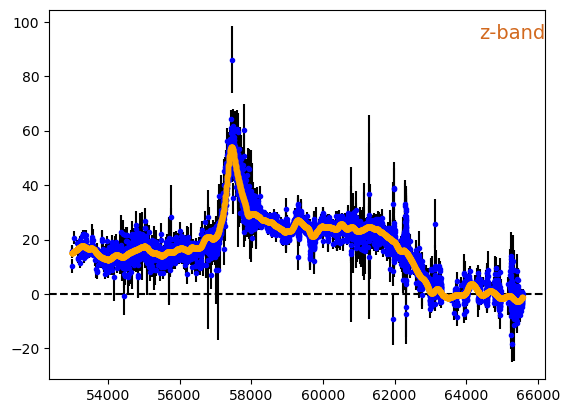

In [15]:
### Plot final segment-connected, aligned data and model

# plt.errorbar(fin_combs[2].t['mjd'], fin_combs[2].t['muJyas2'], yerr=fin_combs[2].t['muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_combs[2].t.loc[fin_inds[2],'mjd'], fin_combs[2].t.loc[fin_inds[2],'muJyas2'], yerr=fin_combs[2].t.loc[fin_inds[2],'muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_mods[2].t['mjd'], fin_mods[2].t['muJyas2'], yerr=fin_mods[2].t['muJyas2_err'], fmt='.', ecolor='k', color='orange')
# plt.ylim(-15, 75)
plt.axhline(0, ls='--', color='k')
plt.title('i-band', loc='right', y=0.9, color='darkred', fontsize=14.)
plt.show()

# plt.errorbar(fin_combs[0].t['mjd'], fin_combs[0].t['muJyas2'], yerr=fin_combs[0].t['muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_combs[0].t.loc[fin_inds[0],'mjd'], fin_combs[0].t.loc[fin_inds[0],'muJyas2'], yerr=fin_combs[0].t.loc[fin_inds[0],'muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_mods[0].t['mjd'], fin_mods[0].t['muJyas2'], yerr=fin_mods[0].t['muJyas2_err'], fmt='.', ecolor='k', color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('g-band', loc='right', y=0.9, color='blue', fontsize=14.)
plt.show()

# plt.errorbar(fin_combs[1].t['mjd'], fin_combs[1].t['muJyas2'], yerr=fin_combs[1].t['muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_combs[1].t.loc[fin_inds[1],'mjd'], fin_combs[1].t.loc[fin_inds[1],'muJyas2'], yerr=fin_combs[1].t.loc[fin_inds[1],'muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_mods[1].t['mjd'], fin_mods[1].t['muJyas2'], yerr=fin_mods[1].t['muJyas2_err'], fmt='.', ecolor='k', color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('r-band', loc='right', y=0.9, color='red', fontsize=14.)
plt.show()

# plt.errorbar(fin_combs[3].t['mjd'], fin_combs[3].t['muJyas2'], yerr=fin_combs[3].t['muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_combs[3].t.loc[fin_inds[3],'mjd'], fin_combs[3].t.loc[fin_inds[3],'muJyas2'], yerr=fin_combs[3].t.loc[fin_inds[3],'muJyas2_err'], fmt='.', ecolor='black', color='blue')
plt.errorbar(fin_mods[3].t['mjd'], fin_mods[3].t['muJyas2'], yerr=fin_mods[3].t['muJyas2_err'], fmt='.', ecolor='k', color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('z-band', loc='right', y=0.9, color='chocolate', fontsize=14.)
plt.show()